# Cost and accuracy of long-term memory frameworks

## 0. Setup

Loads the raw experiment CSVs, deduplicates retried sessions, tags each row
with its network scenario (unconstrained / constrained), coerces numeric
columns, and excludes the rows that the paper's analysis treats as outliers.
All downstream sections consume the cleaned `ask`, `load`, and `ask_scored`
DataFrames produced here.

### 0.1 Imports and plot style

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['STIXGeneral', 'Times New Roman', 'Nimbus Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'font.size': 9,
    'axes.labelsize': 9, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'legend.fontsize': 8, 'legend.framealpha': 0.9, 'figure.dpi': 150,
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False,
})
SINGLE_COL = (3.5, 2.8)
DOUBLE_COL = (7.16, 3.0)
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)

### 0.2 Constants

`FRAMEWORKS` lists the five evaluated systems by internal key (snake_case).
`FRAMEWORK_LABEL` maps each key to the paper-facing display label.

In [2]:
FRAMEWORKS = ['cognee', 'full_context', 'graphiti', 'mem0', 'rag']
FRAMEWORK_LABEL = {'mem0': 'Mem0', 'rag': 'RAG', 'full_context': 'full-context',
                   'graphiti': 'Graphiti', 'cognee': 'cognee'}
FRAMEWORK_LABELS = [FRAMEWORK_LABEL[f] for f in FRAMEWORKS]
COLORS  = {'mem0': '#2563eb', 'rag': '#16a34a', 'full_context': '#ca8a04',
           'graphiti': '#dc2626', 'cognee': '#9333ea'}
HATCHES = {'mem0': '', 'rag': '///', 'full_context': '...',
           'graphiti': 'xxx', 'cognee': '\\\\'}
MARKERS = {'mem0': 'o', 'rag': 's', 'full_context': '^',
           'graphiti': 'D', 'cognee': 'v'}

SCENARIOS = ['unconstrained', 'constrained']
SCORED_CATEGORIES = {1, 2, 3, 4}
CAT_LABEL = {1: 'single-hop', 2: 'multi-hop', 3: 'temporal', 4: 'open-domain'}
PHASE_LABEL = {'load': 'Loading', 'ask': r'Q\&A'}
GROUP = ['memory', 'scenario']
EXPECTED_CONVS = set(range(10))

### 0.3 Load CSV results

Each conversation may appear in multiple CSVs from retried sessions; the
latest `session_id` per `(memory, mode, conversation)` is kept.

In [3]:
RESULTS_DIR = Path('../results')
if not any(RESULTS_DIR.glob('*.csv')):
    RESULTS_DIR = Path('../results/backup')
print(f'Loading from: {RESULTS_DIR.resolve()}')

frames = [pd.read_csv(p, dtype={'question': str})
          for p in sorted(RESULTS_DIR.glob('*.csv')) if p.stat().st_size > 0]
raw_all = pd.concat(frames, ignore_index=True)
raw_all['timestamp'] = pd.to_datetime(raw_all['timestamp'], utc=True, errors='coerce')

latest = (raw_all.groupby(['memory', 'mode', 'conversation_index', 'session_id'])['timestamp']
          .max().reset_index().sort_values('timestamp')
          .drop_duplicates(subset=['memory', 'mode', 'conversation_index'], keep='last')
          [['memory', 'mode', 'conversation_index', 'session_id']])
raw = raw_all.merge(latest, on=['memory', 'mode', 'conversation_index', 'session_id'])
print(f'Loaded {len(raw)} rows across {raw["memory"].nunique()} frameworks.')

Loading from: /home/jacobbista/Documents/RM&SW/Experiment/dmas-long-context-memory/testbed/experiments/results
Loaded 74320 rows across 5 frameworks.


### 0.4 Scenario tag and numeric coercion

The derived `scenario` column is the canonical name used throughout the
notebook. The original `mode` column is left intact for traceability.

In [4]:
con_mask = ((raw['toxic_latency'].fillna(0) > 0) |
            (raw['toxic_jitter'].fillna(0) > 0) |
            (raw['toxic_bandwidth'].fillna(0) > 0))
raw['scenario'] = con_mask.map({True: 'constrained', False: 'unconstrained'})
raw['correct'] = (raw['judge_verdict'] == 'CORRECT').astype(float)

num_cols = ['wall_ms', 'compute_ms', 'flush_ms', 'cpu_edge_ns', 'cpu_cloud_ns',
            'ram_edge_peak_bytes', 'ram_cloud_peak_bytes',
            'disk_edge_bytes', 'disk_cloud_bytes',
            'network_edge_to_cloud_bytes', 'network_cloud_to_edge_bytes',
            'edge_llm_tokens', 'cloud_llm_tokens', 'llm_tokens',
            'edge_llm_cost_usd', 'cloud_llm_cost_usd', 'llm_cost_usd',
            'responder_context_window_tokens', 'responder_context_window_cost_usd',
            'cloud_llm_retry_wait_ms', 'search_calls', 'top_k', 'memories_returned',
            'toxic_latency', 'toxic_jitter', 'toxic_bandwidth']
for c in num_cols:
    if c in raw.columns:
        raw[c] = pd.to_numeric(raw[c], errors='coerce')

### 0.5 Plot helper

Single-bar plot per framework, used by later figures. Output saved into
`figures/`.

In [5]:
def framework_bar(vals, ylabel, savename, logy=False, annotate=None):
    fig, ax = plt.subplots(figsize=SINGLE_COL)
    x = np.arange(len(FRAMEWORKS))
    bars = ax.bar(x, vals, color=[COLORS[f] for f in FRAMEWORKS],
                  edgecolor='black', linewidth=0.5)
    if annotate:
        ax.bar_label(bars, labels=[annotate(v) for v in vals], padding=2, fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(FRAMEWORK_LABELS, rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    if logy:
        ax.set_yscale('log')
    plt.tight_layout()
    plt.savefig(FIG_DIR / savename, bbox_inches='tight')
    plt.show()

## 1. Validation and cleanup

Inspect the raw dataset before any rows are removed: schema, conversation
coverage, network-scenario configuration, error and retry counts,
search-call distribution, monotonicity of load-phase LLM cost. The
cleanup at the end (§1.7) removes the two row classes identified as
outliers, producing the `raw`, `ask`, `load`, and `ask_scored` DataFrames
consumed by all later sections.

### 1.1 Schema and coverage

In [6]:
ask_raw  = raw[raw['phase'] == 'ask']
load_raw = raw[raw['phase'] == 'load']
ask_scored_raw = ask_raw[ask_raw['question_category'].isin(SCORED_CATEGORIES)]

print(f'Columns ({len(raw.columns)}):')
print(list(raw.columns))
print('\nPhases:', sorted(raw['phase'].dropna().unique()))
print('Question categories:', sorted(raw['question_category'].dropna().unique()))

cov = ask_scored_raw.groupby(GROUP)['conversation_index'].apply(
    lambda s: sorted(set(s.unique()))).rename('convs_found')
missing = ask_scored_raw.groupby(GROUP)['conversation_index'].apply(
    lambda s: sorted(EXPECTED_CONVS - set(s.unique()))).rename('missing')
cov_df = pd.concat([cov, missing], axis=1)
cov_df['complete'] = cov_df['missing'].apply(lambda x: len(x) == 0)
display(cov_df)
print(f'All cells complete: {cov_df["complete"].all()}')

Columns (48):
['experiment_name', 'timestamp', 'session_id', 'trace_id', 'judge_trace_id', 'phase', 'memory', 'mode', 'conversation_index', 'turn_index', 'question_index', 'search_calls', 'top_k', 'memories_returned', 'question_category', 'question', 'answer', 'gold_answer', 'seed', 'judge_n', 'judge_verdict', 'judge_reason', 'toxic_latency', 'toxic_jitter', 'toxic_bandwidth', 'wall_ms', 'compute_ms', 'flush_ms', 'cpu_edge_ns', 'cpu_cloud_ns', 'ram_edge_peak_bytes', 'ram_cloud_peak_bytes', 'disk_edge_bytes', 'disk_cloud_bytes', 'network_edge_to_cloud_bytes', 'network_cloud_to_edge_bytes', 'edge_llm_tokens', 'edge_llm_cost_usd', 'cloud_llm_tokens', 'cloud_llm_cost_usd', 'llm_tokens', 'llm_cost_usd', 'responder_context_window_tokens', 'responder_context_window_cost_usd', 'cloud_llm_retry_wait_ms', 'error', 'scenario', 'correct']

Phases: ['ask', 'load', 'warmup']
Question categories: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


convs_found missing  complete
memory       scenario                                                       
cognee       constrained    [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]      []      True
             unconstrained  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]      []      True
full_context constrained    [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]      []      True
             unconstrained  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]      []      True
graphiti     constrained    [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]      []      True
             unconstrained  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]      []      True
mem0         constrained    [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]      []      True
             unconstrained  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]      []      True
rag          constrained    [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]      []      True
             unconstrained  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]      []      True

All cells complete: True


### 1.2 Network scenario configuration

In [7]:
tox = ask_raw.groupby('scenario')[['toxic_latency','toxic_jitter','toxic_bandwidth']].agg(['mean','min','max'])
display(tox)
wrong = ask_raw[((ask_raw['scenario'] == 'constrained')   & (ask_raw['toxic_latency'] == 0)) |
                ((ask_raw['scenario'] == 'unconstrained') & (ask_raw['toxic_latency'] > 0))]
print(f'Rows with inconsistent toxic configuration: {len(wrong)}')

toxic_latency               toxic_jitter              \
                       mean    min    max         mean   min   max   
scenario                                                             
constrained           150.0  150.0  150.0         30.0  30.0  30.0   
unconstrained           0.0    0.0    0.0          0.0   0.0   0.0   

              toxic_bandwidth                
                         mean    min    max  
scenario                                     
constrained             512.0  512.0  512.0  
unconstrained             0.0    0.0    0.0

Rows with inconsistent toxic configuration: 0


### 1.3 Errors and retries

Error rows are responder failures recorded in the `error` column.
Full-context concentrates all errors due to context-window overflows on
long conversations. The framework-level rate is reported below.

In [8]:
errors = raw[raw['error'].notna() & (raw['error'].astype(str).str.strip() != '')]
err_ask = errors[errors['phase'] == 'ask']

print(f'Total rows: {len(raw):,}')
print(f'Error rows: {len(errors)} ({100*len(errors)/len(raw):.2f}% of all rows)')
print(f'  by phase: {errors["phase"].value_counts().astype(int).to_dict()}')
 
err_by_fw = err_ask.groupby(['memory','scenario']).size().rename('n_errors')
ask_by_fw = ask_raw.groupby(['memory','scenario']).size().rename('n_asks')
err_pct = pd.concat([err_by_fw, ask_by_fw], axis=1).fillna(0).astype(int)
err_pct['pct_of_framework_asks'] = (100 * err_pct['n_errors'] / err_pct['n_asks']).round(2)
print('\nError ask rows by framework and scenario:')
display(err_pct)

retried = raw[raw['cloud_llm_retry_wait_ms'].fillna(0) > 0]
print(f'\nRows with retry wait: {len(retried)}')

judge_nan = ask_raw[ask_raw['judge_verdict'].isna()]
print(f'Rows with missing judge verdict: {len(judge_nan)}')

Total rows: 74,320
Error rows: 20 (0.03% of all rows)
  by phase: {'ask': 20}

Error ask rows by framework and scenario:


n_errors  n_asks  pct_of_framework_asks
memory       scenario                                              
full_context constrained          13    1540                   0.84
             unconstrained         7    1540                   0.45
cognee       constrained           0    1540                   0.00
             unconstrained         0    1540                   0.00
graphiti     constrained           0    1540                   0.00
             unconstrained         0    1540                   0.00
mem0         constrained           0    1540                   0.00
             unconstrained         0    1540                   0.00
rag          constrained           0    1540                   0.00
             unconstrained         0    1540                   0.00


Rows with retry wait: 0
Rows with missing judge verdict: 20


### 1.4 Search-call distribution

Multi-search Q&A rows are responder turns that issued more than one
`search_memories` call. The paper reports the overall multi-search rate.

In [9]:
dist = ask_raw.groupby(['memory','scenario','search_calls']).size().unstack(fill_value=0)
dist.columns = [f'{int(c)}_call{"s" if c != 1 else ""}' for c in dist.columns]
display(dist)

mask_multi = ask_raw['search_calls'].fillna(0) > 1
n_multi = int(mask_multi.sum())
print(f'Total ask rows: {len(ask_raw):,}')
print(f'Multi-search ask rows: {n_multi} '
      f'({100*n_multi/len(ask_raw):.2f}% of asks)')

multi_pct = pd.DataFrame({
    'n_multi':  ask_raw[mask_multi].groupby(['memory','scenario']).size(),
    'n_asks':   ask_raw.groupby(['memory','scenario']).size(),
}).fillna(0).astype(int)
multi_pct['pct_of_framework_asks'] = (100 * multi_pct['n_multi'] / multi_pct['n_asks']).round(2)
print('\nMulti-search ask rows by framework and scenario:')
display(multi_pct)

1_call  2_calls  3_calls  4_calls  5_calls
memory       scenario                                                 
cognee       constrained      1504       30        4        1        1
             unconstrained    1507       30        2        1        0
full_context constrained      1513       12        2        0        0
             unconstrained    1515       15        3        0        0
graphiti     constrained      1536        4        0        0        0
             unconstrained    1531        8        1        0        0
mem0         constrained      1537        3        0        0        0
             unconstrained    1538        2        0        0        0
rag          constrained      1536        3        1        0        0
             unconstrained    1535        3        2        0        0

Total ask rows: 15,400
Multi-search ask rows: 128 (0.83% of asks)

Multi-search ask rows by framework and scenario:


n_multi  n_asks  pct_of_framework_asks
memory       scenario                                             
cognee       constrained         36    1540                   2.34
             unconstrained       33    1540                   2.14
full_context constrained         14    1540                   0.91
             unconstrained       18    1540                   1.17
graphiti     constrained          4    1540                   0.26
             unconstrained        9    1540                   0.58
mem0         constrained          3    1540                   0.19
             unconstrained        2    1540                   0.13
rag          constrained          4    1540                   0.26
             unconstrained        5    1540                   0.32

### 1.5 Loading-phase cost monotonicity

A LiteLLM upstream issue had previously caused per-call `cloud_llm_cost_usd`
to drift cumulatively across load-phase rows of the same framework, producing
a small number of rows whose cost was far above the group mean. This check
flags any group where more than 1% of rows exceed 10× the group mean.

In [10]:
print('Load-cost accumulation check (frac of rows >10x group mean, >1% = SUSPECT):')
for g, gdf in load_raw.groupby(GROUP):
    v = gdf['cloud_llm_cost_usd'].dropna()
    if len(v) == 0 or v.mean() == 0:
        print(f'  {g}: no cost data')
        continue
    mean = v.mean()
    frac_10x = (v > 10 * mean).mean()
    n_10x = (v > 10 * mean).sum()
    flag = '  SUSPECT' if frac_10x > 0.01 else ''
    print(f'  {g}: {n_10x}/{len(v)} rows >10x mean ({frac_10x*100:.2f}%)  '
          f'mean=${mean:.6f}  max=${v.max():.6f}{flag}')

Load-cost accumulation check (frac of rows >10x group mean, >1% = SUSPECT):
  ('cognee', 'constrained'): 1/5882 rows >10x mean (0.02%)  mean=$0.000224  max=$0.003007
  ('cognee', 'unconstrained'): 0/5882 rows >10x mean (0.00%)  mean=$0.000224  max=$0.001839
  ('full_context', 'constrained'): no cost data
  ('full_context', 'unconstrained'): no cost data
  ('graphiti', 'constrained'): 0/5882 rows >10x mean (0.00%)  mean=$0.000934  max=$0.002663
  ('graphiti', 'unconstrained'): 0/5882 rows >10x mean (0.00%)  mean=$0.000933  max=$0.002504
  ('mem0', 'constrained'): 0/5882 rows >10x mean (0.00%)  mean=$0.000819  max=$0.001483
  ('mem0', 'unconstrained'): 0/5882 rows >10x mean (0.00%)  mean=$0.000820  max=$0.001399
  ('rag', 'constrained'): 0/5882 rows >10x mean (0.00%)  mean=$0.000001  max=$0.000003
  ('rag', 'unconstrained'): 0/5882 rows >10x mean (0.00%)  mean=$0.000001  max=$0.000003


### 1.6 Outlier exclusion

Now the two row classes flagged in §1.3 and §1.4 are dropped. The
cleaned `raw`, `ask`, `load`, and `ask_scored` DataFrames are the input
to every later section. `ask_scored` further filters to the four scored
LoCoMo categories.

In [11]:
multi_search_ask = raw[(raw['phase'] == 'ask') & (raw['search_calls'].fillna(0) > 1)]
drop_idx = errors.index.union(multi_search_ask.index)

raw = raw.drop(index=drop_idx).copy()
ask  = raw[raw['phase'] == 'ask'].copy()
load = raw[raw['phase'] == 'load'].copy()
ask_scored = ask[ask['question_category'].isin(SCORED_CATEGORIES)].copy()

print(f'Removed {len(drop_idx)} rows '
      f'({len(errors)} errors, {len(multi_search_ask)} multi-search asks, '
      f'{len(errors.index.intersection(multi_search_ask.index))} overlap).')
print(f'Clean rows: raw={len(raw)}, ask={len(ask)}, '
      f'ask_scored={len(ask_scored)}, load={len(load)}.')

Removed 148 rows (20 errors, 128 multi-search asks, 0 overlap).
Clean rows: raw=74172, ask=15252, ask_scored=15252, load=58820.


### 1.7 Effective ask counts after cleanup

In [12]:
n_original = ask_raw.groupby(['memory','scenario']).size().rename('n_original')
n_removed_error = (err_ask.groupby(['memory','scenario']).size()
                          .reindex(n_original.index, fill_value=0).rename('n_removed_error'))
n_removed_multi = (multi_search_ask.groupby(['memory','scenario']).size()
                                   .reindex(n_original.index, fill_value=0).rename('n_removed_multi'))
n_eff = ask.groupby(['memory','scenario']).size().reindex(n_original.index, fill_value=0).rename('n_eff')

eff_counts = (pd.concat([n_original, n_removed_error, n_removed_multi, n_eff], axis=1)
              .assign(pct_removed=lambda d: (100 * (d['n_removed_error'] + d['n_removed_multi'])
                                             / d['n_original']).round(2)))
print('Effective ask counts per (memory, scenario) after cleanup:')
display(eff_counts)
print(f'Totals: n_original={n_original.sum()}  '
      f'n_removed_error={n_removed_error.sum()}  '
      f'n_removed_multi={n_removed_multi.sum()}  '
      f'n_eff={n_eff.sum()}')

Effective ask counts per (memory, scenario) after cleanup:


n_original  n_removed_error  n_removed_multi  \
memory       scenario                                                      
cognee       constrained          1540                0               36   
             unconstrained        1540                0               33   
full_context constrained          1540               13               14   
             unconstrained        1540                7               18   
graphiti     constrained          1540                0                4   
             unconstrained        1540                0                9   
mem0         constrained          1540                0                3   
             unconstrained        1540                0                2   
rag          constrained          1540                0                4   
             unconstrained        1540                0                5   

                            n_eff  pct_removed  
memory       scenario                           
cognee       constrained     1504         2.34  
             unconstrained   1507         2.14  
full_context constrained     1513         1.75  
             unconstrained   1515         1.62  
graphiti     constrained     1536         0.26  
             unconstrained   1531         0.58  
mem0         constrained     1537         0.19  
             unconstrained   1538         0.13  
rag          constrained     1536         0.26  
             unconstrained   1535         0.32

Totals: n_original=15400  n_removed_error=20  n_removed_multi=128  n_eff=15252


## 2. Accuracy and retrieval

Per-conversation accuracy is the unit of analysis (n=10). Macro accuracy
averages the ten per-conversation rates; the same convention is used for
incorrect and unknown rates, so the three rates sum to 100% by row. The
paper's Table III is generated here. All Wilcoxon tests are paired on the
ten conversations.

### 2.1 Per-conversation accuracy

In [13]:
per_conv = (ask_scored.groupby(['memory','scenario','conversation_index'])
            .agg(correct=('correct','sum'), n=('correct','count'))
            .assign(acc=lambda x: x['correct']/x['n'])
            .reset_index())
pivot_unc = (per_conv[per_conv.scenario=='unconstrained']
             .pivot(index='conversation_index', columns='memory', values='acc')[FRAMEWORKS])
pivot_con = (per_conv[per_conv.scenario=='constrained']
             .pivot(index='conversation_index', columns='memory', values='acc')[FRAMEWORKS])

print('Constrained per-conversation accuracy:')
print(pivot_con.to_string(float_format='{:.3f}'.format))
print('\nMean and standard deviation:')
print(pivot_con.agg(['mean','std']).to_string(float_format='{:.3f}'.format))

Constrained per-conversation accuracy:
memory              cognee  full_context  graphiti  mem0   rag
conversation_index                                            
0                    0.530         0.822     0.579 0.836 0.855
1                    0.575         0.852     0.667 0.840 0.877
2                    0.603         0.730     0.596 0.809 0.848
3                    0.469         0.774     0.518 0.754 0.707
4                    0.582         0.710     0.596 0.758 0.781
5                    0.546         0.769     0.492 0.802 0.756
6                    0.544         0.791     0.510 0.846 0.738
7                    0.559         0.791     0.529 0.827 0.780
8                    0.566         0.797     0.516 0.814 0.737
9                    0.555         0.680     0.601 0.823 0.752

Mean and standard deviation:
memory  cognee  full_context  graphiti  mem0   rag
mean     0.553         0.772     0.560 0.811 0.783
std      0.036         0.052     0.056 0.032 0.057


### 2.2 Macro accuracy, incorrect and unknown (Table III)

Each rate is computed per conversation, then averaged across the ten;
$\pm$ denotes the sample standard deviation across conversations.

In [14]:
unknown_str = "don't know based on the given context"
asd = ask_scored.assign(
    _unknown=ask_scored['answer'].apply(
        lambda a: isinstance(a, str) and unknown_str in a.lower()))

per_conv_full = (asd.groupby(['memory','scenario','conversation_index'])
                 .agg(correct=('correct','sum'),
                      unknown=('_unknown','sum'),
                      n=('correct','count'))
                 .assign(acc=lambda x: x['correct'] / x['n'],
                         incorrect=lambda x: (x['n'] - x['correct'] - x['unknown']) / x['n'],
                         unknown_rate=lambda x: x['unknown'] / x['n'])
                 .reset_index())

retention = (per_conv_full.groupby(['memory','scenario'])[['acc','incorrect','unknown_rate']]
             .agg(['mean','std']).mul(100).round(2))
retention.columns = ['acc_macro','acc_sd','incorrect_macro','incorrect_sd',
                     'unknown_macro','unknown_sd']
retention = retention.reset_index()
print('Macro retention metrics (mean of per-conversation rates +/- SD):')
print(retention.sort_values(['scenario','memory']).to_string(index=False))

Macro retention metrics (mean of per-conversation rates +/- SD):
      memory      scenario  acc_macro  acc_sd  incorrect_macro  incorrect_sd  unknown_macro  unknown_sd
      cognee   constrained      55.27    3.60            16.55          5.11          28.18        4.92
full_context   constrained      77.16    5.21            13.17          3.50           9.67        5.40
    graphiti   constrained      56.03    5.56            18.39          3.47          25.58        3.38
        mem0   constrained      81.08    3.19            10.54          2.64           8.38        2.14
         rag   constrained      78.31    5.75            10.56          3.61          11.14        3.95
      cognee unconstrained      54.80    4.21            16.43          4.22          28.77        4.70
full_context unconstrained      76.98    5.59            13.68          3.82           9.33        5.33
    graphiti unconstrained      55.19    4.00            19.78          2.93          25.03        4.89

LaTeX (Table III, constrained scenario):

In [15]:
def _pm(mean, sd):
    return f'{mean:.2f} $\\pm$ {sd:.2f}'

ret_con = (retention[retention['scenario'] == 'constrained']
           .set_index('memory').reindex(FRAMEWORKS))

retention_latex = [
    r'\begin{table}[t]',
    r'\centering',
    (r'\caption{Macro retention metrics in the constrained network scenario. '
     r'Accuracy, incorrect, and unknown rates are computed per conversation '
     r'and averaged over the ten conversations; $\pm$ denotes the sample '
     r'standard deviation across conversations.}'),
    r'\label{tab:retention}',
    r'\begin{tabular}{l rrr}',
    r'\toprule',
    (r'\textbf{Framework} & \textbf{Accuracy (\%)} & \textbf{Incorrect (\%)} '
     r'& \textbf{Unknown (\%)} \\'),
    r'\midrule',
]
for m in FRAMEWORKS:
    r = ret_con.loc[m]
    retention_latex.append(
        f'{FRAMEWORK_LABEL[m]} & '
        f'{_pm(r["acc_macro"], r["acc_sd"])} & '
        f'{_pm(r["incorrect_macro"], r["incorrect_sd"])} & '
        f'{_pm(r["unknown_macro"], r["unknown_sd"])} \\\\'
    )
retention_latex += [r'\bottomrule', r'\end{tabular}', r'\end{table}']
print('\n'.join(retention_latex))

\begin{table}[t]
\centering
\caption{Macro retention metrics in the constrained network scenario. Accuracy, incorrect, and unknown rates are computed per conversation and averaged over the ten conversations; $\pm$ denotes the sample standard deviation across conversations.}
\label{tab:retention}
\begin{tabular}{l rrr}
\toprule
\textbf{Framework} & \textbf{Accuracy (\%)} & \textbf{Incorrect (\%)} & \textbf{Unknown (\%)} \\
\midrule
cognee & 55.27 $\pm$ 3.60 & 16.55 $\pm$ 5.11 & 28.18 $\pm$ 4.92 \\
full-context & 77.16 $\pm$ 5.21 & 13.17 $\pm$ 3.50 & 9.67 $\pm$ 5.40 \\
Graphiti & 56.03 $\pm$ 5.56 & 18.39 $\pm$ 3.47 & 25.58 $\pm$ 3.38 \\
Mem0 & 81.08 $\pm$ 3.19 & 10.54 $\pm$ 2.64 & 8.38 $\pm$ 2.14 \\
RAG & 78.31 $\pm$ 5.75 & 10.56 $\pm$ 3.61 & 11.14 $\pm$ 3.95 \\
\bottomrule
\end{tabular}
\end{table}


### 2.3 Pairwise Wilcoxon, framework × framework

Ten pairwise comparisons across the five frameworks. Bonferroni-corrected
threshold $\alpha = 0.05 / 10 = 0.005$. Both scenarios reported so the
cluster structure can be checked under either.

In [16]:
COMPARISONS = [
    ('mem0','rag'), ('mem0','full_context'), ('mem0','graphiti'), ('mem0','cognee'),
    ('rag','full_context'), ('rag','graphiti'), ('rag','cognee'),
    ('full_context','graphiti'), ('full_context','cognee'),
    ('graphiti','cognee'),
]
BONFERRONI = 0.05 / len(COMPARISONS)
print(f'Bonferroni-corrected significance level: {BONFERRONI:.4f}')

def paired_w(a, b, la, lb, alpha=BONFERRONI):
    diff = a - b
    if (diff == 0).all():
        return dict(comparison=f'{la} vs {lb}', mean_diff=0.0, W=0.0, p=1.0, sig=False)
    W, p = wilcoxon(a, b)
    return dict(comparison=f'{la} vs {lb}', mean_diff=float(diff.mean()),
                W=float(W), p=float(p), sig=bool(p < alpha))

for label, pivot in [('unconstrained', pivot_unc), ('constrained', pivot_con)]:
    res = [paired_w(pivot[a].values, pivot[b].values, a, b) for a,b in COMPARISONS]
    tab = pd.DataFrame(res); tab['significant'] = tab['sig'].map({True:'yes', False:'no'})
    print(f'\n{label}:')
    print(tab[['comparison','mean_diff','W','p','significant']]
          .to_string(index=False, float_format='{:.4f}'.format))

Bonferroni-corrected significance level: 0.0050

unconstrained:
              comparison  mean_diff       W      p significant
             mem0 vs rag     0.0053 22.0000 0.6250          no
    mem0 vs full_context     0.0236 12.0000 0.1309          no
        mem0 vs graphiti     0.2415  0.0000 0.0020         yes
          mem0 vs cognee     0.2454  0.0000 0.0020         yes
     rag vs full_context     0.0182 12.0000 0.4609          no
         rag vs graphiti     0.2361  0.0000 0.0020         yes
           rag vs cognee     0.2401  0.0000 0.0020         yes
full_context vs graphiti     0.2179  0.0000 0.0020         yes
  full_context vs cognee     0.2219  0.0000 0.0020         yes
      graphiti vs cognee     0.0039 24.0000 0.7695          no

constrained:
              comparison  mean_diff       W      p significant
             mem0 vs rag     0.0277 10.0000 0.0840          no
    mem0 vs full_context     0.0392  5.0000 0.0195          no
        mem0 vs graphiti     0.2505  0.0

### 2.4 Scenario invariance

Per-framework paired Wilcoxon (constrained vs unconstrained accuracy).
Family of $k=5$ tests $\Rightarrow$ Bonferroni-corrected threshold $\alpha = 0.01$.

In [17]:
BONF_ACC = 0.05 / len(FRAMEWORKS)
print(f'Accuracy change (constrained minus unconstrained), paired Wilcoxon.')
print(f'Bonferroni-corrected threshold across k={len(FRAMEWORKS)} tests: alpha = {BONF_ACC:.3f}')
for m in FRAMEWORKS:
    u = pivot_unc[m].values; c = pivot_con[m].values
    if (c-u).std() == 0:
        print(f'  {m:13} no variation'); continue
    W, p = wilcoxon(c, u)
    tag_raw  = 'sig' if p<0.05     else 'n.s.'
    tag_bonf = 'sig' if p<BONF_ACC else 'n.s.'
    print(f'  {m:13} delta={c.mean()-u.mean():+.3f}  p={p:.4f}  raw={tag_raw:5} bonf={tag_bonf}')

Accuracy change (constrained minus unconstrained), paired Wilcoxon.
Bonferroni-corrected threshold across k=5 tests: alpha = 0.010
  cognee        delta=+0.005  p=0.6953  raw=n.s.  bonf=n.s.
  full_context  delta=+0.002  p=0.7344  raw=n.s.  bonf=n.s.
  graphiti      delta=+0.008  p=0.6953  raw=n.s.  bonf=n.s.
  mem0          delta=+0.017  p=0.0742  raw=n.s.  bonf=n.s.
  rag           delta=-0.005  p=0.6406  raw=n.s.  bonf=n.s.


### 2.5 Accuracy boxplot (Fig. 3)

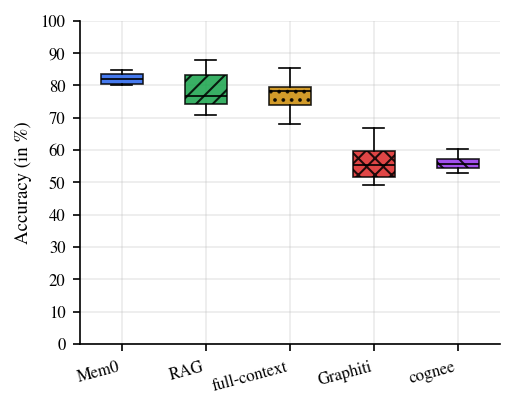

In [18]:
FRAMEWORKS_RANKED = ['mem0', 'rag', 'full_context', 'graphiti', 'cognee']
FRAMEWORK_LABELS_RANKED = [FRAMEWORK_LABEL[f] for f in FRAMEWORKS_RANKED]

def boxplot_panel(pivot, savename):
    fig, ax = plt.subplots(figsize=SINGLE_COL)
    data = [pivot[m].values * 100 for m in FRAMEWORKS_RANKED]
    bp = ax.boxplot(data, tick_labels=FRAMEWORK_LABELS_RANKED, patch_artist=True,
                    widths=0.5, showfliers=False)
    for patch, m in zip(bp['boxes'], FRAMEWORKS_RANKED):
        patch.set_facecolor(COLORS[m]); patch.set_hatch(HATCHES[m])
        patch.set_alpha(0.85); patch.set_edgecolor('black'); patch.set_linewidth(0.8)
    for el in ['whiskers','caps','medians']:
        plt.setp(bp[el], color='black', linewidth=0.8)
    ax.set_ylabel('Accuracy (in %)')
    ax.set_ylim(0, 100)
    ax.set_yticks(range(0, 101, 10))
    ax.set_xticklabels(FRAMEWORK_LABELS_RANKED, rotation=15, ha='right')
    plt.tight_layout()
    plt.savefig(FIG_DIR/savename, bbox_inches='tight')
    plt.show()

boxplot_panel(pivot_con, 'fig_accuracy.pdf')

## 3. Question categories

Per-category accuracy under the constrained scenario (Table IV). Computed
as the per-conversation per-category rate, averaged over the ten
conversations. Descriptive only: the per-category per-conversation sample
size is too small for hypothesis testing.

### 3.1 Per-category accuracy

In [19]:
per_conv_cat = (ask_scored
                .groupby(['scenario','memory','conversation_index','question_category'])
                .agg(correct=('correct','sum'), n=('correct','count'))
                .assign(rate=lambda d: 100 * d['correct'] / d['n'])
                .reset_index())

cat_macro = (per_conv_cat
             .groupby(['scenario','memory','question_category'])['rate']
             .mean().round(2))

rows = []
for m in FRAMEWORKS:
    row = {'framework': FRAMEWORK_LABEL[m]}
    for cat in [1, 2, 3, 4]:
        try:
            row[CAT_LABEL[cat]] = f'{cat_macro.loc[("constrained", m, cat)]:.2f}'
        except KeyError:
            row[CAT_LABEL[cat]] = 'n/a'
    rows.append(row)
print('Per-category accuracy, constrained scenario (mean across the 10 conversations):')
print(pd.DataFrame(rows).set_index('framework').to_string())

Per-category accuracy, constrained scenario (mean across the 10 conversations):
             single-hop multi-hop temporal open-domain
framework                                             
cognee            52.79     29.88    43.14       67.66
full-context      67.94     62.84    36.65       89.75
Graphiti          56.00     52.59    31.83       59.85
Mem0              71.09     74.79    55.48       88.81
RAG               72.12     73.08    45.32       85.30


## 4. System-level cost

Resource consumption and cost per framework, broken down by phase
(loading vs Q&A) and scenario. The paper's Table II is generated in §4.2.
TCO uses AWS Fargate us-east-1 on-demand pricing applied uniformly to all
frameworks.

### 4.1 Resource metrics

`peak_at_phase_end` is built by chronological cumsum of `ram_*_peak_bytes`
per framework (warmup $\rightarrow$ load $\rightarrow$ ask across both
scenario legs). `memory.peak` is a monotonic high-water that is reset once
per framework, at the start of the constrained leg. Summing the per-row
deltas grouped only by `memory` gives the running peak, so the constrained
leg inherits the unconstrained leg's end-of-leg peak as baseline. Edge RAM
$\approx$ 2.3-2.6 GB across memory-using frameworks is the resident
qwen2.5:3b SLM; cloud RAM is the per-framework signal.

In [20]:
chrono = (raw[raw['phase'].isin(['warmup','load','ask'])]
          .sort_values(['memory','timestamp'])
          .copy())
chrono['ram_edge_running_bytes']  = chrono.groupby('memory')['ram_edge_peak_bytes'].cumsum()
chrono['ram_cloud_running_bytes'] = chrono.groupby('memory')['ram_cloud_peak_bytes'].cumsum()
peak_at_phase_end = (chrono.groupby(['memory','scenario','phase'])
                     .agg(ram_edge_peak_gb =('ram_edge_running_bytes',  lambda s: s.iloc[-1] / 1e9),
                          ram_cloud_peak_gb=('ram_cloud_running_bytes', lambda s: s.iloc[-1] / 1e9)))

sub = raw[raw['phase'].isin(['load','ask'])]
g = sub.groupby(['memory','scenario','phase'])
metrics = pd.DataFrame(index=g.size().index)
metrics['wall_hr']      = g['wall_ms'].sum() / 1000 / 3600
metrics['cpu_edge_hr']  = g['cpu_edge_ns'].sum()  / 1e9 / 3600
metrics['cpu_cloud_hr'] = g['cpu_cloud_ns'].sum() / 1e9 / 3600
metrics = metrics.join(peak_at_phase_end[['ram_edge_peak_gb','ram_cloud_peak_gb']])
metrics['disk_edge_io_gb']  = g['disk_edge_bytes'].sum()  / 1e9
metrics['disk_cloud_io_gb'] = g['disk_cloud_bytes'].sum() / 1e9
metrics['net_edge_to_cloud_gb'] = g['network_edge_to_cloud_bytes'].sum() / 1e9
metrics['net_cloud_to_edge_gb'] = g['network_cloud_to_edge_bytes'].sum() / 1e9
metrics['edge_llm_tokens']    = g['edge_llm_tokens'].sum()
metrics['cloud_llm_tokens']   = g['cloud_llm_tokens'].sum()
metrics['edge_llm_cost_usd']  = g['edge_llm_cost_usd'].sum()
metrics['cloud_llm_cost_usd'] = g['cloud_llm_cost_usd'].sum()

order = pd.MultiIndex.from_product(
    [FRAMEWORKS, ['constrained'], ['load','ask']],
    names=['memory','scenario','phase'])
metrics = metrics.reindex(order).dropna(how='all')
display(metrics.round(4))

wall_hr  cpu_edge_hr  cpu_cloud_hr  \
memory       scenario    phase                                       
cognee       constrained load    8.4433       0.0946        4.3648   
                         ask     2.9295       5.1953        0.7991   
full_context constrained load    0.6102       0.0130        0.0161   
                         ask     3.8874       5.0846        0.0912   
graphiti     constrained load    9.6939       0.1127        0.5600   
                         ask     2.7594       5.2479        0.2715   
mem0         constrained load    4.4382       0.0611        0.2614   
                         ask     2.0443       5.7491        0.0721   
rag          constrained load    0.9277       0.0168        0.0810   
                         ask     1.8987       5.1812        0.0589   

                                ram_edge_peak_gb  ram_cloud_peak_gb  \
memory       scenario    phase                                        
cognee       constrained load             2.8412             1.0351   
                         ask              2.8412             1.0380   
full_context constrained load             0.0455             0.0190   
                         ask              0.0524             0.0190   
graphiti     constrained load             2.8570             0.8922   
                         ask              2.8570             0.8922   
mem0         constrained load             2.7861             0.1321   
                         ask              2.7861             0.1321   
rag          constrained load             2.4670             0.0790   
                         ask              2.5012             0.0798   

                                disk_edge_io_gb  disk_cloud_io_gb  \
memory       scenario    phase                                      
cognee       constrained load            0.0009           21.6647   
                         ask             0.0000            0.1761   
full_context constrained load            0.0001            0.0012   
                         ask             0.0000            0.0038   
graphiti     constrained load            0.0000            7.9045   
                         ask             0.0001            0.0175   
mem0         constrained load            0.0000            2.1560   
                         ask             0.0000            0.0042   
rag          constrained load            0.0000            0.9932   
                         ask             0.0000            0.0051   

                                net_edge_to_cloud_gb  net_cloud_to_edge_gb  \
memory       scenario    phase                                               
cognee       constrained load                 0.0077                0.0055   
                         ask                  0.0016                0.0012   
full_context constrained load                 0.0078                0.0053   
                         ask                  0.0016                0.0014   
graphiti     constrained load                 0.0076                0.0054   
                         ask                  0.0016                0.0013   
mem0         constrained load                 0.0076                0.0054   
                         ask                  0.0016                0.0014   
rag          constrained load                 0.0076                0.0055   
                         ask                  0.0016                0.0013   

                                edge_llm_tokens  cloud_llm_tokens  \
memory       scenario    phase                                      
cognee       constrained load                 0           6682740   
                         ask             336411           6708983   
full_context constrained load                 0                 0   
                         ask             337174          66521608   
graphiti     constrained load                 0          34579780   
                         ask             343796           6343193   
mem0         constra

### 4.2 LaTeX Table II — system-level cost per phase

Constrained scenario, both phases. CPU in hours; RAM peak, disk I/O and
network in MB. RAM peak is reconstructed as a cumulative high-water,
using the unconstrained-leg per-framework sum as baseline plus the
constrained-leg per-phase growth. RAG and full-context share an EC2
instance, so full-context's edge-RAM baseline is taken from RAG.
Subtotal and total RAM peaks are the maximum across frameworks (not a
sum) since peaks on separate instances are not additive.

In [21]:
paper = (metrics
         .xs('constrained', level='scenario')
         .reorder_levels(['phase','memory']))
order_pm = pd.MultiIndex.from_product([['load','ask'], FRAMEWORKS],
                                       names=['phase','memory'])

GB_TO_MB = 1000.0
DISPLAY_COLS = [
    'latency_total_hr',
    'cpu_cloud_hr', 'ram_cloud_peak_mb', 'disk_cloud_io_mb', 'net_cloud_to_edge_mb',
    'llm_cost_usd',
    'cpu_edge_hr',  'ram_edge_peak_mb',  'disk_edge_io_mb',  'net_edge_to_cloud_mb',
]
RAM_COLS = {'ram_cloud_peak_mb', 'ram_edge_peak_mb'}

_con = raw[(raw['scenario'] == 'constrained') & raw['phase'].isin(['load','ask'])]
llm_phase_tab = _con.groupby(['phase','memory'])['llm_cost_usd'].sum()
lat_phase_tab = _con.groupby(['phase','memory'])['wall_ms'].sum() / (1000.0 * 3600.0)

paper = paper.reindex(order_pm).assign(
    cpu_cloud_hr          = lambda d: d['cpu_cloud_hr'],
    ram_cloud_peak_mb     = lambda d: d['ram_cloud_peak_gb']     * GB_TO_MB,
    disk_cloud_io_mb      = lambda d: d['disk_cloud_io_gb']      * GB_TO_MB,
    net_cloud_to_edge_mb  = lambda d: d['net_cloud_to_edge_gb']  * GB_TO_MB,
    cpu_edge_hr           = lambda d: d['cpu_edge_hr'],
    ram_edge_peak_mb      = lambda d: d['ram_edge_peak_gb']      * GB_TO_MB,
    disk_edge_io_mb       = lambda d: d['disk_edge_io_gb']       * GB_TO_MB,
    net_edge_to_cloud_mb  = lambda d: d['net_edge_to_cloud_gb']  * GB_TO_MB,
    llm_cost_usd          = lambda d: llm_phase_tab.reindex(d.index).values,
    latency_total_hr      = lambda d: lat_phase_tab.reindex(d.index).values,
)[DISPLAY_COLS].round(2)

# RAM peak: cumulative high-water reconstruction.
# Baseline = unconstrained per-framework sum. Constrained per-phase growth
# is added on top, producing a running total (Q&A >= Loading).
# RAG and full-context share an EC2 instance, so full-context's edge-RAM
# baseline (its own reads ~19 MB because RAG crossed the shared high-water
# first) is taken from RAG.
def _ram_mb(scen, col, phase=None):
    d = raw[raw['scenario'] == scen]
    if phase is not None:
        d = d[d['phase'] == phase]
    return (d.groupby('memory')[col].sum() / 1e6).reindex(FRAMEWORKS).fillna(0.0)

for _col, _mb in [('ram_edge_peak_bytes', 'ram_edge_peak_mb'),
                  ('ram_cloud_peak_bytes', 'ram_cloud_peak_mb')]:
    _base = _ram_mb('unconstrained', _col)
    if _col == 'ram_edge_peak_bytes':
        _base['full_context'] = _base['rag']
    _gl = _ram_mb('constrained', _col, 'load')
    _ga = _ram_mb('constrained', _col, 'ask')
    _load_peak = _base + _gl
    _ask_peak  = _base + _gl + _ga
    for _m in FRAMEWORKS:
        paper.loc[('load', _m), _mb] = round(_load_peak[_m], 2)
        paper.loc[('ask',  _m), _mb] = round(_ask_peak[_m],  2)

def _tex(s):  return s.replace('_', r'\_')
def _fmt_cell(col, val):
    s = f'{val:,.2f}'
    if col == 'llm_cost_usd':
        return rf'\${s}'
    return s

lines = [
    r'\begin{table*}[t]',
    r'\centering',
    r'\caption{System-level cost of three LTM frameworks and two baselines in the constrained cloud-edge network scenario. The RAM peak subtotals and total reflect the highest peak identified during experimentation.}',
    r'\label{tab:resource_cost}',
    r'\begin{tabular}{ll r rrrrr rrrr}',
    r'\toprule',
    (r' & &'
     r' & \multicolumn{5}{c}{\textbf{Cloud}}'
     r' & \multicolumn{4}{c}{\textbf{Edge}} \\'),
    r'\cmidrule(lr){4-8} \cmidrule(lr){9-12}',
    (r' & & \textbf{Latency}'
     r' & \textbf{CPU} & \textbf{RAM peak} & \textbf{Disk I/O} & \textbf{Network}'
     r' & \textbf{OpenAI}'
     r' & \textbf{CPU} & \textbf{RAM peak} & \textbf{Disk I/O} & \textbf{Network} \\'),
    (r'\textbf{Phase} & \textbf{Framework} & (hours)'
     r' & (hours) & (MB) & (MB) & (MB) & (USD)'
     r' & (hours) & (MB) & (MB) & (MB) \\'),
    r'\midrule',
]

phase_subtotals = {}
for pi, ph in enumerate(['load','ask']):
    block = paper.xs(ph, level='phase')
    span = len(FRAMEWORKS) + 1
    for i, (mem, row) in enumerate(block.iterrows()):
        ph_cell = (f'\\multirow{{{span}}}{{*}}{{{PHASE_LABEL[ph]}}}'
                   if i == 0 else '')
        lines.append(
            f'{ph_cell} & {_tex(FRAMEWORK_LABEL[mem])} & '
            + ' & '.join(_fmt_cell(c, row[c]) for c in DISPLAY_COLS)
            + r' \\'
        )
    subtotal = block[DISPLAY_COLS].sum()
    submax   = block[DISPLAY_COLS].max()
    phase_subtotals[ph] = subtotal
    lines.append(r'\cmidrule(l){2-12}')
    lines.append(
        r' & \textit{Subtotal} & '
        + ' & '.join(f'\\textit{{{_fmt_cell(c, (submax if c in RAM_COLS else subtotal)[c])}}}' for c in DISPLAY_COLS)
        + r' \\'
    )
    if pi < 1:
        lines.append(r'\midrule')

grand_total = sum(phase_subtotals.values())
grand_max   = paper[DISPLAY_COLS].max()
lines.append(r'\midrule')
lines.append(
    r'\multicolumn{2}{l}{\textbf{Total}} & '
    + ' & '.join(f'\\textbf{{{_fmt_cell(c, (grand_max if c in RAM_COLS else grand_total)[c])}}}' for c in DISPLAY_COLS)
    + r' \\'
)
lines += [r'\bottomrule', r'\end{tabular}', r'\end{table*}']
print('\n'.join(lines))

\begin{table*}[t]
\centering
\caption{System-level cost of three LTM frameworks and two baselines in the constrained cloud-edge network scenario. The RAM peak subtotals and total reflect the highest peak identified during experimentation.}
\label{tab:resource_cost}
\begin{tabular}{ll r rrrrr rrrr}
\toprule
 & & & \multicolumn{5}{c}{\textbf{Cloud}} & \multicolumn{4}{c}{\textbf{Edge}} \\
\cmidrule(lr){4-8} \cmidrule(lr){9-12}
 & & \textbf{Latency} & \textbf{CPU} & \textbf{RAM peak} & \textbf{Disk I/O} & \textbf{Network} & \textbf{OpenAI} & \textbf{CPU} & \textbf{RAM peak} & \textbf{Disk I/O} & \textbf{Network} \\
\textbf{Phase} & \textbf{Framework} & (hours) & (hours) & (MB) & (MB) & (MB) & (USD) & (hours) & (MB) & (MB) & (MB) \\
\midrule
\multirow{6}{*}{Loading} & cognee & 8.44 & 4.36 & 962.97 & 21,664.74 & 5.48 & \$1.32 & 0.09 & 2,562.79 & 0.92 & 7.69 \\
 & full-context & 0.61 & 0.02 & 18.39 & 1.23 & 5.27 & \$0.00 & 0.01 & 2,343.19 & 0.11 & 7.80 \\
 & Graphiti & 9.69 & 0.56 & 866.93 & 

### 4.3 Loading-phase aggregates

Per-framework loading time, summed resource consumption, and OpenAI cost
in the constrained scenario. These are the numbers cited verbatim in the
paper's "Loading Long-Term Memory" paragraph.

In [22]:
lu = load[load.scenario == 'constrained']

load_agg = {
    'total_load_time_hr':   lu['wall_ms'].sum() / 1000 / 3600,
    'cloud_cpu_hr':         lu['cpu_cloud_ns'].sum() / 1e9 / 3600,
    'edge_cpu_hr':          lu['cpu_edge_ns'].sum() / 1e9 / 3600,
    'cloud_disk_io_mb':     lu['disk_cloud_bytes'].sum() / 1e6,
    'edge_disk_io_mb':      lu['disk_edge_bytes'].sum() / 1e6,
    'net_edge_to_cloud_mb': lu['network_edge_to_cloud_bytes'].sum() / 1e6,
    'net_cloud_to_edge_mb': lu['network_cloud_to_edge_bytes'].sum() / 1e6,
    'openai_cost_usd':      lu['cloud_llm_cost_usd'].sum(),
}
print('Loading-phase totals (constrained, summed over frameworks):')
for k, v in load_agg.items():
    print(f'  {k:22} {v:.3f}')

print('\nPer-framework loading:')
load_by_fw = lu.groupby('memory').agg(
    hours              =('wall_ms',                lambda s: s.sum()/1000/3600),
    cloud_disk_io_mb   =('disk_cloud_bytes',       lambda s: s.sum()/1e6),
    cloud_ram_peak_mb  =('ram_cloud_peak_bytes',   lambda s: s.sum()/1e6),
    openai_cost_usd    =('cloud_llm_cost_usd',     'sum'),
).reindex(FRAMEWORKS).round(2)
display(load_by_fw)

Loading-phase totals (constrained, summed over frameworks):
  total_load_time_hr     24.113
  cloud_cpu_hr           5.283
  edge_cpu_hr            0.298
  cloud_disk_io_mb       32719.684
  edge_disk_io_mb        1.044
  net_edge_to_cloud_mb   38.387
  net_cloud_to_edge_mb   27.062
  openai_cost_usd        11.635

Per-framework loading:


,hours,cloud_disk_io_mb,cloud_ram_peak_mb,openai_cost_usd
memory,,,,
cognee,8.44,21664.74,107.29,1.32
full_context,0.61,1.23,0.00,0.00
graphiti,9.69,7904.48,194.83,5.49
mem0,4.44,2156.02,8.59,4.82
rag,0.93,993.21,4.24,0.01


### 4.4 Q&A-phase aggregates

Same structure for the Q&A phase. Cited in the paper's "Answering Questions
Using Long-Term Memory" paragraph.

In [23]:
au = ask[ask.scenario == 'constrained']

ask_agg = {
    'total_ask_time_hr':    au['wall_ms'].sum() / 1000 / 3600,
    'cloud_cpu_hr':         au['cpu_cloud_ns'].sum() / 1e9 / 3600,
    'edge_cpu_hr':          au['cpu_edge_ns'].sum() / 1e9 / 3600,
    'cloud_disk_io_mb':     au['disk_cloud_bytes'].sum() / 1e6,
    'edge_disk_io_mb':      au['disk_edge_bytes'].sum() / 1e6,
    'net_edge_to_cloud_mb': au['network_edge_to_cloud_bytes'].sum() / 1e6,
    'net_cloud_to_edge_mb': au['network_cloud_to_edge_bytes'].sum() / 1e6,
    'openai_cost_usd':      au['cloud_llm_cost_usd'].sum(),
}
print('Q&A-phase totals (constrained, summed over frameworks):')
for k, v in ask_agg.items():
    print(f'  {k:22} {v:.3f}')

print('\nPer-framework Q&A:')
ask_by_fw = au.groupby('memory').agg(
    hours              =('wall_ms',                lambda s: s.sum()/1000/3600),
    edge_disk_io_mb    =('disk_edge_bytes',        lambda s: s.sum()/1e6),
    net_cloud_to_edge_mb=('network_cloud_to_edge_bytes', lambda s: s.sum()/1e6),
    cloud_ram_peak_mb  =('ram_cloud_peak_bytes',   lambda s: s.sum()/1e6),
    openai_cost_usd    =('cloud_llm_cost_usd',     'sum'),
).reindex(FRAMEWORKS).round(2)
display(ask_by_fw)

Q&A-phase totals (constrained, summed over frameworks):
  total_ask_time_hr      13.519
  cloud_cpu_hr           1.293
  edge_cpu_hr            26.458
  cloud_disk_io_mb       206.635
  edge_disk_io_mb        0.094
  net_edge_to_cloud_mb   8.017
  net_cloud_to_edge_mb   6.619
  openai_cost_usd        12.724

Per-framework Q&A:


,hours,edge_disk_io_mb,net_cloud_to_edge_mb,cloud_ram_peak_mb,openai_cost_usd
memory,,,,,
cognee,2.93,0.00,1.22,38.66,1.05
full_context,3.89,0.00,1.41,0.57,10.01
graphiti,2.76,0.07,1.27,9.31,1.00
mem0,2.04,0.01,1.39,5.52,0.27
rag,1.90,0.00,1.34,9.75,0.40


### 4.5 Total cost of ownership

TCO sums edge infrastructure, cloud infrastructure, and OpenAI API usage at
the AWS Fargate us-east-1 on-demand rates. RAM is priced at the chronological
running peak per framework (the level Fargate would reserve), multiplied by
wall-clock hours. Egress is priced for cloud $\rightarrow$ edge traffic
only; AWS does not charge ingress. The warmup phase is excluded.

In [24]:
VCPU_PER_HOUR        = 0.04048
RAM_GB_HOUR          = 0.004445
CLOUD_EGRESS_PER_GB  = 0.09
CLOUD_INGRESS_PER_GB = 0.00
PHASES_ORDER = ['load', 'ask']

ram_prov_gb = (peak_at_phase_end
               .groupby('memory')[['ram_edge_peak_gb','ram_cloud_peak_gb']]
               .max()
               .rename(columns={'ram_edge_peak_gb':  'ram_edge_gb',
                                'ram_cloud_peak_gb': 'ram_cloud_gb'}))

_sub = raw[raw['phase'].isin(PHASES_ORDER)]
_g   = _sub.groupby(['memory','scenario','phase'])
phase_cost = pd.DataFrame({
    'wall_hr':              _g['wall_ms'].sum()                     / 1000 / 3600,
    'cpu_edge_hr':          _g['cpu_edge_ns'].sum()                 / 1e9  / 3600,
    'cpu_cloud_hr':         _g['cpu_cloud_ns'].sum()                / 1e9  / 3600,
    'net_cloud_to_edge_gb': _g['network_cloud_to_edge_bytes'].sum() / 1e9,
    'net_edge_to_cloud_gb': _g['network_edge_to_cloud_bytes'].sum() / 1e9,
    'llm_api':              _g['llm_cost_usd'].sum(),
})
_mems = phase_cost.index.get_level_values('memory')
phase_cost['ram_edge_gb']  = _mems.map(ram_prov_gb['ram_edge_gb'])
phase_cost['ram_cloud_gb'] = _mems.map(ram_prov_gb['ram_cloud_gb'])
phase_cost['edge_infra']   = (phase_cost['cpu_edge_hr']           * VCPU_PER_HOUR
                              + phase_cost['ram_edge_gb']  * phase_cost['wall_hr'] * RAM_GB_HOUR)
phase_cost['cloud_infra']  = (phase_cost['cpu_cloud_hr']          * VCPU_PER_HOUR
                              + phase_cost['ram_cloud_gb'] * phase_cost['wall_hr'] * RAM_GB_HOUR
                              + phase_cost['net_cloud_to_edge_gb'] * CLOUD_EGRESS_PER_GB
                              + phase_cost['net_edge_to_cloud_gb'] * CLOUD_INGRESS_PER_GB)
phase_cost['tco']          = phase_cost['edge_infra'] + phase_cost['cloud_infra'] + phase_cost['llm_api']

_audit_cols = ['edge_infra','cloud_infra','llm_api','tco']
_con_phase  = phase_cost.xs('constrained', level='scenario')[_audit_cols]
_con_total  = _con_phase.groupby('memory').sum()
_con_total.index = pd.MultiIndex.from_product([FRAMEWORKS, ['TOTAL']],
                                              names=['memory','phase'])
_audit_idx  = pd.MultiIndex.from_tuples(
    [(m, p) for m in FRAMEWORKS for p in PHASES_ORDER + ['TOTAL']],
    names=['memory','phase'])
tco_audit_constrained = pd.concat([_con_phase, _con_total]).reindex(_audit_idx)

print('Constrained-scenario TCO with per-phase partials (USD):')
print('(load + ask == TOTAL by construction)')
display(tco_audit_constrained.round(3))

tco = (phase_cost.groupby(['memory','scenario'])[['cloud_infra','edge_infra','llm_api']].sum())
tco['tco'] = tco['cloud_infra'] + tco['edge_infra'] + tco['llm_api']
print('\nTCO summary (both scenarios, USD):')
display(tco.round(3))

Constrained-scenario TCO with per-phase partials (USD):
(load + ask == TOTAL by construction)


edge_infra  cloud_infra  llm_api     tco
memory       phase                                          
cognee       load        0.110        0.216    1.318   1.644
             ask         0.247        0.046    1.053   1.346
             TOTAL       0.358        0.262    2.371   2.991
full_context load        0.001        0.001    0.000   0.002
             ask         0.207        0.004   10.006  10.217
             TOTAL       0.207        0.005   10.006  10.219
graphiti     load        0.128        0.062    5.492   5.682
             ask         0.247        0.022    0.995   1.265
             TOTAL       0.375        0.084    6.488   6.947
mem0         load        0.057        0.014    4.819   4.890
             ask         0.258        0.004    0.274   0.536
             TOTAL       0.315        0.018    5.092   5.426
rag          load        0.011        0.004    0.006   0.021
             ask         0.231        0.003    0.396   0.630
             TOTAL       0.242        0.007    0.402   0.651


TCO summary (both scenarios, USD):


cloud_infra  edge_infra  llm_api     tco
memory       scenario                                               
cognee       constrained          0.262       0.358    2.371   2.991
             unconstrained        0.262       0.355    2.373   2.991
full_context constrained          0.005       0.207   10.006  10.219
             unconstrained        0.005       0.206   10.025  10.237
graphiti     constrained          0.084       0.375    6.488   6.947
             unconstrained        0.082       0.370    6.489   6.941
mem0         constrained          0.018       0.315    5.092   5.426
             unconstrained        0.018       0.312    5.096   5.426
rag          constrained          0.007       0.242    0.402   0.651
             unconstrained        0.007       0.237    0.402   0.646

## 5. Cost-accuracy trade-off

The constrained scenario is the comparison context.

### 5.1 Pareto frontier (Fig. 2)

Plotted (TCO, accuracy) pairs (constrained):
              tco_usd  accuracy_%
cognee          2.991      55.273
full_context   10.219      77.155
graphiti        6.947      56.028
mem0            5.426      81.078
rag             0.651      78.307


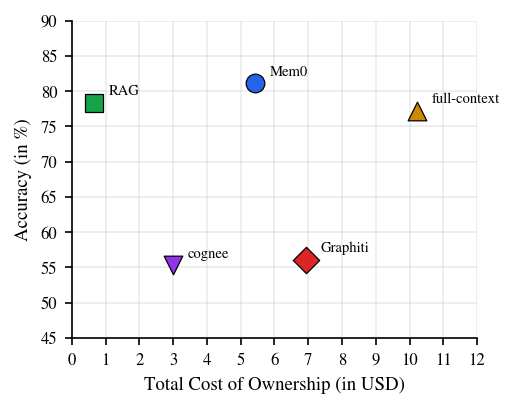

In [25]:
tco_con  = tco.xs('constrained', level='scenario')
acc_mean = pivot_con.mean()

print('Plotted (TCO, accuracy) pairs (constrained):')
print(pd.DataFrame({'tco_usd':    [tco_con.loc[m, 'tco']  for m in FRAMEWORKS],
                    'accuracy_%': [acc_mean[m] * 100       for m in FRAMEWORKS]},
                   index=FRAMEWORKS).round(3).to_string())

fig, ax = plt.subplots(figsize=SINGLE_COL)
for m in FRAMEWORKS:
    ax.scatter(tco_con.loc[m,'tco'], acc_mean[m]*100, color=COLORS[m], marker=MARKERS[m],
               s=80, edgecolor='black', linewidth=0.6, zorder=3)
    ax.annotate(FRAMEWORK_LABEL[m], (tco_con.loc[m,'tco'], acc_mean[m]*100),
                xytext=(7, 4), textcoords='offset points', fontsize=7)
ax.set_xlabel('Total Cost of Ownership (in USD)')
ax.set_ylabel('Accuracy (in %)')
ax.set_xlim(0, 12); ax.set_ylim(45, 90)
ax.set_xticks(range(0, 13, 1))
plt.tight_layout()
plt.savefig(FIG_DIR/'fig_pareto.pdf', bbox_inches='tight')
plt.show()

## 6. Network sensitivity

Per-framework paired Wilcoxon on the per-conversation median compute
latency, constrained vs unconstrained. Family of $k=5$ tests
$\Rightarrow$ Bonferroni-corrected threshold $\alpha = 0.01$.

### 6.1 Latency Wilcoxon

In [26]:
BONF_LAT = 0.05 / len(FRAMEWORKS)
rows = []
for m in FRAMEWORKS:
    u = (ask[(ask.memory==m)&(ask.scenario=='unconstrained')]
         .groupby('conversation_index')['compute_ms'].median().sort_index().values)
    c = (ask[(ask.memory==m)&(ask.scenario=='constrained')]
         .groupby('conversation_index')['compute_ms'].median().sort_index().values)
    _, p = wilcoxon(c, u) if (c-u).std() > 0 else (0, 1.0)
    rows.append({'framework': m,
                 'unc_s': u.mean()/1000, 'con_s': c.mean()/1000,
                 'delta_s': (c.mean()-u.mean())/1000,
                 'delta_pct': 100*(c.mean()-u.mean())/u.mean(),
                 'p': p,
                 'sig_raw':  'yes' if p<0.05      else 'no',
                 'sig_bonf': 'yes' if p<BONF_LAT  else 'no'})
print('Per-conversation median compute latency (mean of the ten medians, seconds).')
print(f'Bonferroni-corrected threshold across k={len(FRAMEWORKS)} tests: alpha = {BONF_LAT:.3f}')
print(pd.DataFrame(rows).to_string(index=False, float_format='{:.3f}'.format))

Per-conversation median compute latency (mean of the ten medians, seconds).
Bonferroni-corrected threshold across k=5 tests: alpha = 0.010
   framework  unc_s  con_s  delta_s  delta_pct     p sig_raw sig_bonf
      cognee  6.350  6.451    0.101      1.586 0.432      no       no
full_context  8.309  8.075   -0.234     -2.818 0.625      no       no
    graphiti  5.174  5.376    0.202      3.911 0.084      no       no
        mem0  4.091  4.274    0.183      4.473 0.006     yes      yes
         rag  3.822  3.987    0.166      4.337 0.006     yes      yes
